In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import os
import sys 
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import fitsio as ft
import math

# importing SYSNET modules
# add the absolute path to 'sysnetdev'
home = os.getenv('HOME')
sys.path.insert(0,f'/{home}/sysnetdev/')


from sysnet import SYSNet, Config, TrainedModel
from sysnet.sources import load_checkpoint, LatentEnsemble, MyDataLoader
%matplotlib inline 

In [14]:
plot_dir = '_plots'
if not os.path.exists(plot_dir):
    os.mkdir(plot_dir)
ext = 'png'

In [15]:
nside = 256
def make_hpmap(nside, hpix, value, fill_value=hp.UNSEEN):
    map_ = np.full(12*nside*nside, fill_value=fill_value)
    map_[hpix] = value
    return map_

def plot_hpmap(nside, hpix, value, vlims=None, fill_value=hp.UNSEEN, title='', ax=None):
    if ax is not None:
        plt.sca(ax)
    if vlims is None:
        vmin, vmax = np.percentile(value, [5, 95])
    else:
        vmin, vmax = vlims
    print(vmin,vmax)
    hp.mollview(make_hpmap(nside, hpix, value, fill_value=fill_value),
                min=vmin, max=vmax, rot=120, title=title, hold=True)

##### TEST

In [11]:
# 60589, 60593 healpix
batch_size = 256
data_size = 60589
train = 0.6
test  = 0.2
validation = 0.2
(data_size*train)%batch_size,(data_size*test)%batch_size, (data_size*validation) %batch_size

(1.4000000000014552, 85.80000000000109, 85.80000000000109)

In [2]:
import numpy as np
from sysnet.sources import MyDataLoader

__global_seed__ = 85
input_path = '../input/eBOSS.ELG.NGC.DR7.table.fits'
ld = MyDataLoader(input_path,
                  do_kfold=True,
                  seed=__global_seed__)

num_partitions = 5
batch_size = 256
num_features = ld.df_split[0][0]['features'].shape[1]
axes = np.arange(num_features)

for partition_id in range(0, num_partitions):  # k-fold validation loop
    dataloaders = ld.load_data(batch_size=batch_size,
                               partition_id=partition_id,
                               normalization='z-score',
                               axes=axes)
    for (data, target, fpix, hpix) in dataloaders['train']:
        if data.shape[0] == 1:
            print(data.shape)

In [67]:
dataloaders['train'].dataset.y.shape[0] % batch_size

225

In [1]:
# _sum = 0
# for (data, target, fpix, hpix) in dataloaders['train']:
#     _sum+=1
#     print(data.shape)
# _sum

In [68]:
data.shape


torch.Size([225, 18])

In [28]:
ld.df_split[0][0]['features'].shape

(112353, 18)

In [30]:
187257*.60

112354.2

## using demo data

In [26]:
# tabulated catalog that contains, imaging properties (features), galaxy counts (label), 
# HEALPix index (hpix), and pixel completeness (fracgood)
input_ = ft.read('../input/eBOSS.ELG.NGC.DR7.table.fits')  # read tab. data
print(f'columns in `input`: {input_.dtype}',input_.size)

columns in `input`: [('label', '>f8'), ('hpix', '>i8'), ('features', '>f8', (18,)), ('fracgood', '>f8')] 187257


In [6]:
name_model = 'dnnp'
path_model = '../output/model_test/model_0_2664486226/best.pth.tar'
nn_struct = (4, 20)
kw_model = dict(nnstruct=nn_struct, num_features=18)

tm = TrainedModel(name_model, path_model, **kw_model)

In [7]:
axes = [i for i in range(18)]  # all 18 imaging features used for training
hpix, npred, latent = tm.forward('../input/eBOSS.ELG.NGC.DR7.table.fits', axes=axes, return_latent=True) 

0.4832839192059476 1.5572481841080532


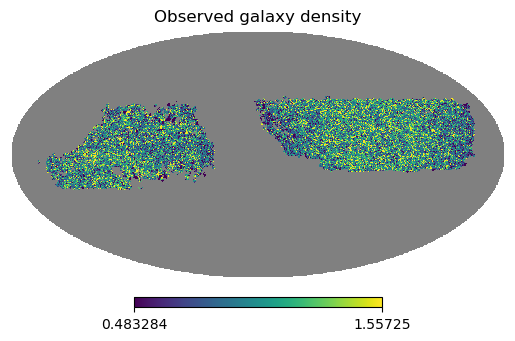

0.8545985460281372 1.2074774265289305


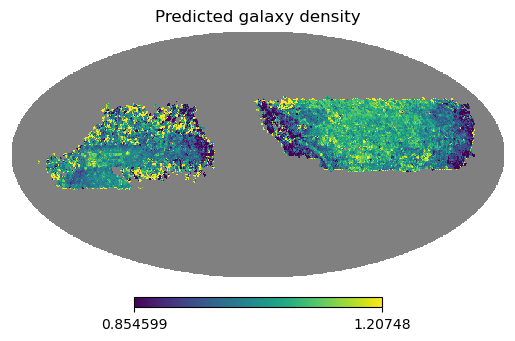

In [8]:
vlims=None
plot_hpmap(nside, input_['hpix'], input_['label'], vlims=vlims, title='Observed galaxy density')
plt.savefig(plot_dir + f'/dens_observed.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

plot_hpmap(nside, hpix, npred, vlims=vlims, title='Predicted galaxy density')
plt.savefig(plot_dir + f'/dens_predicted.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

-0.24412856996059418 -0.24412856996059418
-0.5453863143920898 1.0524903059005712
-0.10774292051792145 2.28021826744079
-0.5860631465911865 1.9097217321395872
-0.13519850373268127 1.3709883213043212
-0.31156817078590393 1.6349092006683335
-0.7824743986129761 0.984558618068695
-0.6129257082939148 1.2124469757080074
-0.08680631965398788 1.6443507194518996
-1.1744050979614258 1.2902118206024167
-0.12691214680671692 -0.12691214680671692
-0.4631754457950592 1.5077470779418929
-0.872758150100708 1.2766881704330428
-0.5186779499053955 1.6244369983673093
-0.5934983491897583 1.4120945215225218
-0.14155010879039764 1.725723934173578
-0.308636873960495 0.03647809028625404
-0.7624090909957886 1.4465221405029258
-0.6234069466590881 0.947909009456634
-0.20523712038993835 0.6851295948028564


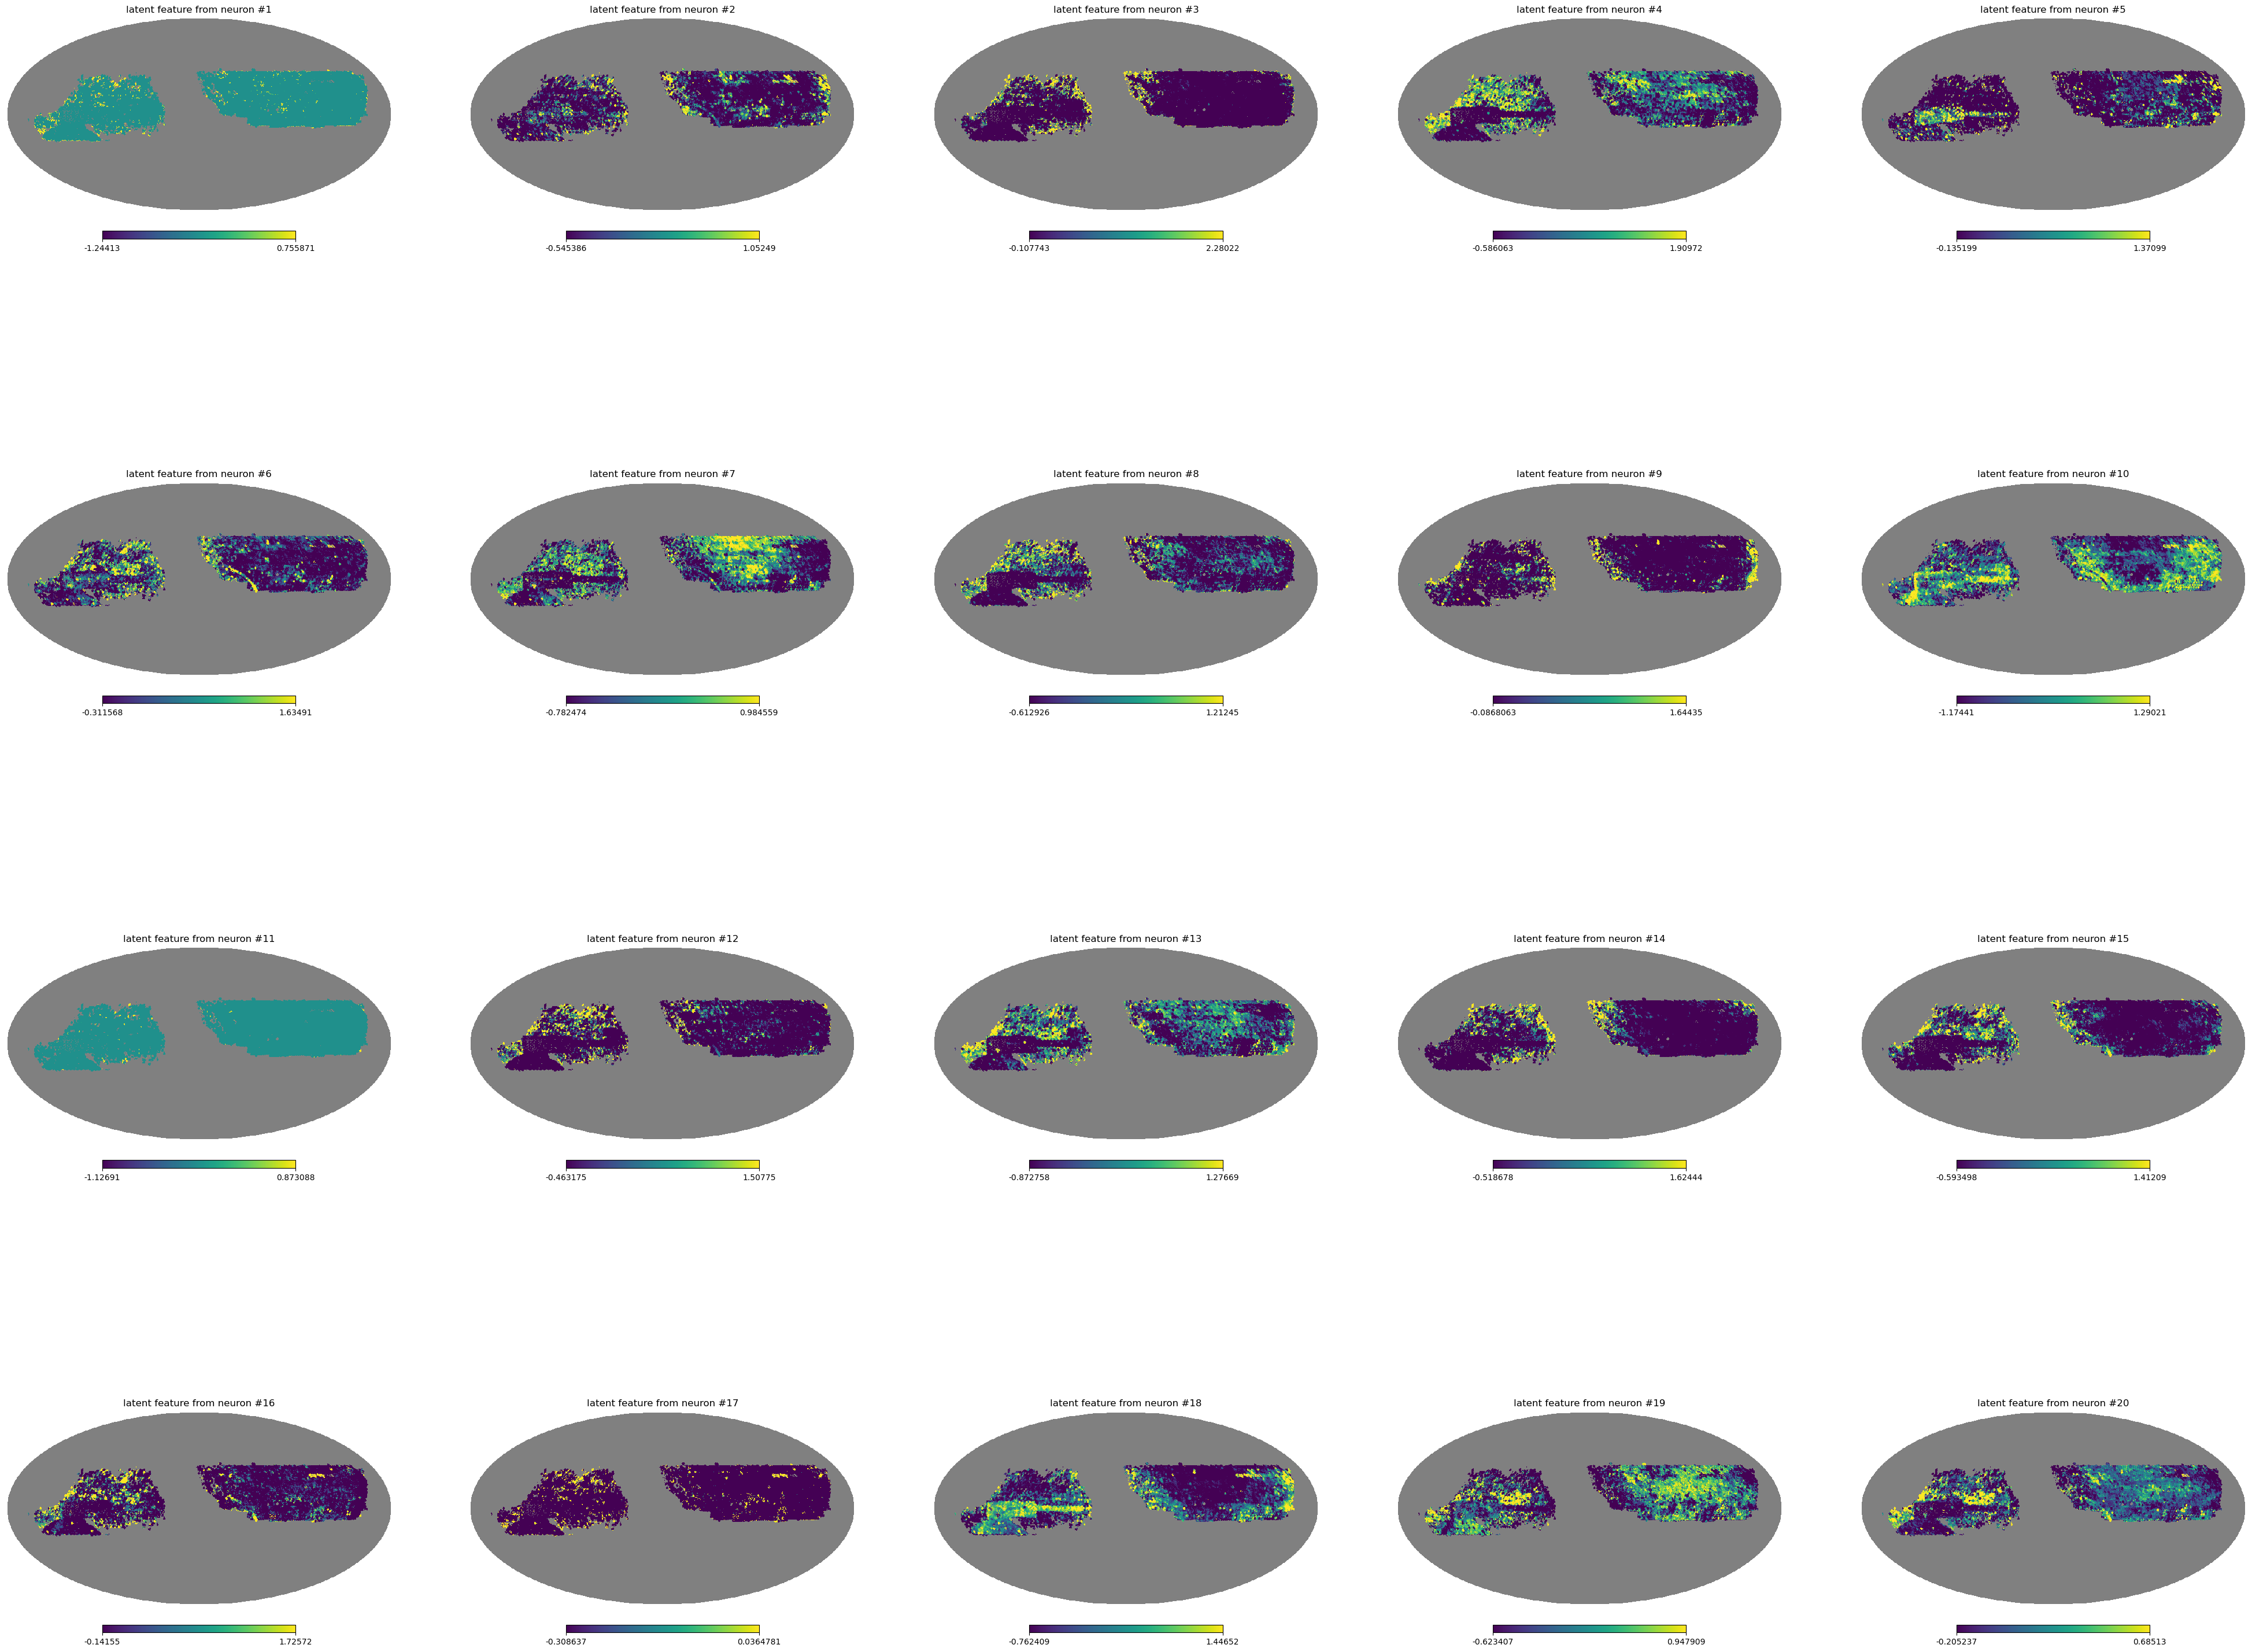

In [9]:
nplots = nn_struct[1]
ncols = math.ceil(math.sqrt(nplots))
nrows = math.ceil(nplots / ncols)
fig, ax = plt.subplots(nrows,ncols,figsize=(10*ncols, 10*nrows))
lax = ax.flatten()

# Region plots
for i in range(nplots):
    plot_hpmap(nside, hpix, latent[:,i], title=f'latent feature from neuron #{i+1}',ax=lax[i])
plt.subplots_adjust(hspace=0.0, wspace=0.0)
fig.savefig(plot_dir + f'/latent_space_features.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

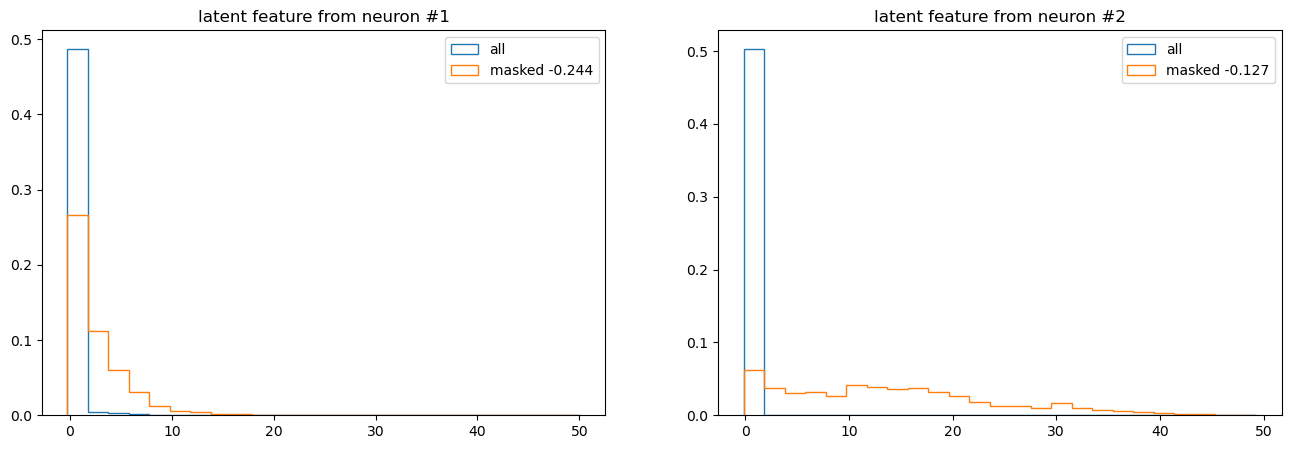

In [10]:
latent_list = [0,10]

nplots = len(latent_list)

ncols = math.ceil(math.sqrt(nplots))
nrows = math.ceil(nplots / ncols)

fig, ax = plt.subplots(nrows,ncols,figsize=(8*ncols, 5*nrows))
lax = ax.flatten()

hist_kws = dict(bins=25,histtype='step',density=True)
for i,ilatent in enumerate(latent_list):
    val = latent[:,ilatent]
    # vmin, vmax = np.percentile(val, [0.1, 99.9])
    # bins  = np.linspace(vmin,vmax,10)
    # cbins = (bins[1:]+bins[:-1]) / 2
    # lax[i].hist(val,bins=cbins,**hist_kws)

    unique, counts = np.unique(val, return_counts=True)
    most_frequent_value = unique[np.argmax(counts)]
    mask = val != most_frequent_value
    
    lax[i].hist(val,label='all',**hist_kws)
    lax[i].hist(val[mask],label=f'masked {most_frequent_value:2.3f}',**hist_kws)
    lax[i].set_title(f'latent feature from neuron #{i+1}')
    lax[i].legend()
# plt.legend()
plt.show()

## now use DESI DR1

In [9]:
# Now with DESI DR1

nn_struct_dict = {'N': (3,10), 'S': (4,20)}
sysnet_dir = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet/'

region = 'S'
sample = f'ELG_LOPnotqso1.1_1.6_{region}'
input_filename = sysnet_dir+f"prep_{sample}.fits"
input_ = ft.read(input_filename)  # read tab. data
num_features = (input_['features'].shape[1])
print(f'columns in `input`: {input_.dtype}')
print(f'number of features used in the regression {num_features}')

name_model = 'dnnp'
path_model = sysnet_dir+f'/{sample}/model_0_2664486226/best.pth.tar'
nn_struct = nn_struct_dict[region]
kw_model = dict(nnstruct=nn_struct, num_features=num_features)

tm = TrainedModel(name_model, path_model, **kw_model)
axes = [i for i in range(num_features)]  # all 18 imaging features used for training
hpix, npred, latent = tm.forward(input_filename, axes=axes, return_latent=True) 

columns in `input`: [('features', '>f8', (10,)), ('label', '>f8'), ('fracgood', '>f8'), ('hpix', '>i8')]
number of features used in the regression 10


0.0 47.722490788183194


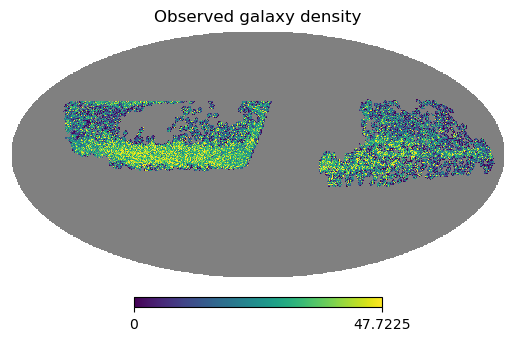

28.940200424194337 42.2224021911621


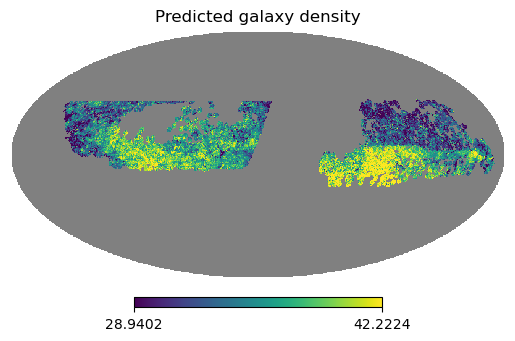

In [12]:
vlims=None
plot_hpmap(nside, input_['hpix'], input_['label'], vlims=vlims, title='Observed galaxy density')
plt.savefig(plot_dir + f'/dens_observed_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

plot_hpmap(nside, hpix, npred, vlims=vlims, title='Predicted galaxy density')
plt.savefig(plot_dir + f'/dens_predicted_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

-2.006309986114502 0.11263457909225992
0.5534108877182007 2.761736512184142
-1.8156344890594482 0.2932494848966598
0.8268799185752869 3.829327178001403
0.982992947101593 3.1669068574905395
-1.5177464485168457 0.7705361247062672
-2.018714666366577 0.2733986854553186
-2.2786471843719482 -0.19924917370080988
-2.0793464183807373 -0.4963997721672059
-1.7637680768966675 0.5992080748081208
-2.089639902114868 -0.06520253345370383
-1.7861754894256592 0.2768916100263589
0.5379537343978882 2.804879856109619
-1.5396431684494019 0.9194029390811893
-1.6693923473358154 0.08078349232673505
-1.9046932458877563 0.7123733639717073
0.5589861273765564 3.0310487508773765
-1.737233281135559 0.6721596121788025
-1.5977448225021362 0.5446160614490465
0.40592339634895325 3.2863972187042236


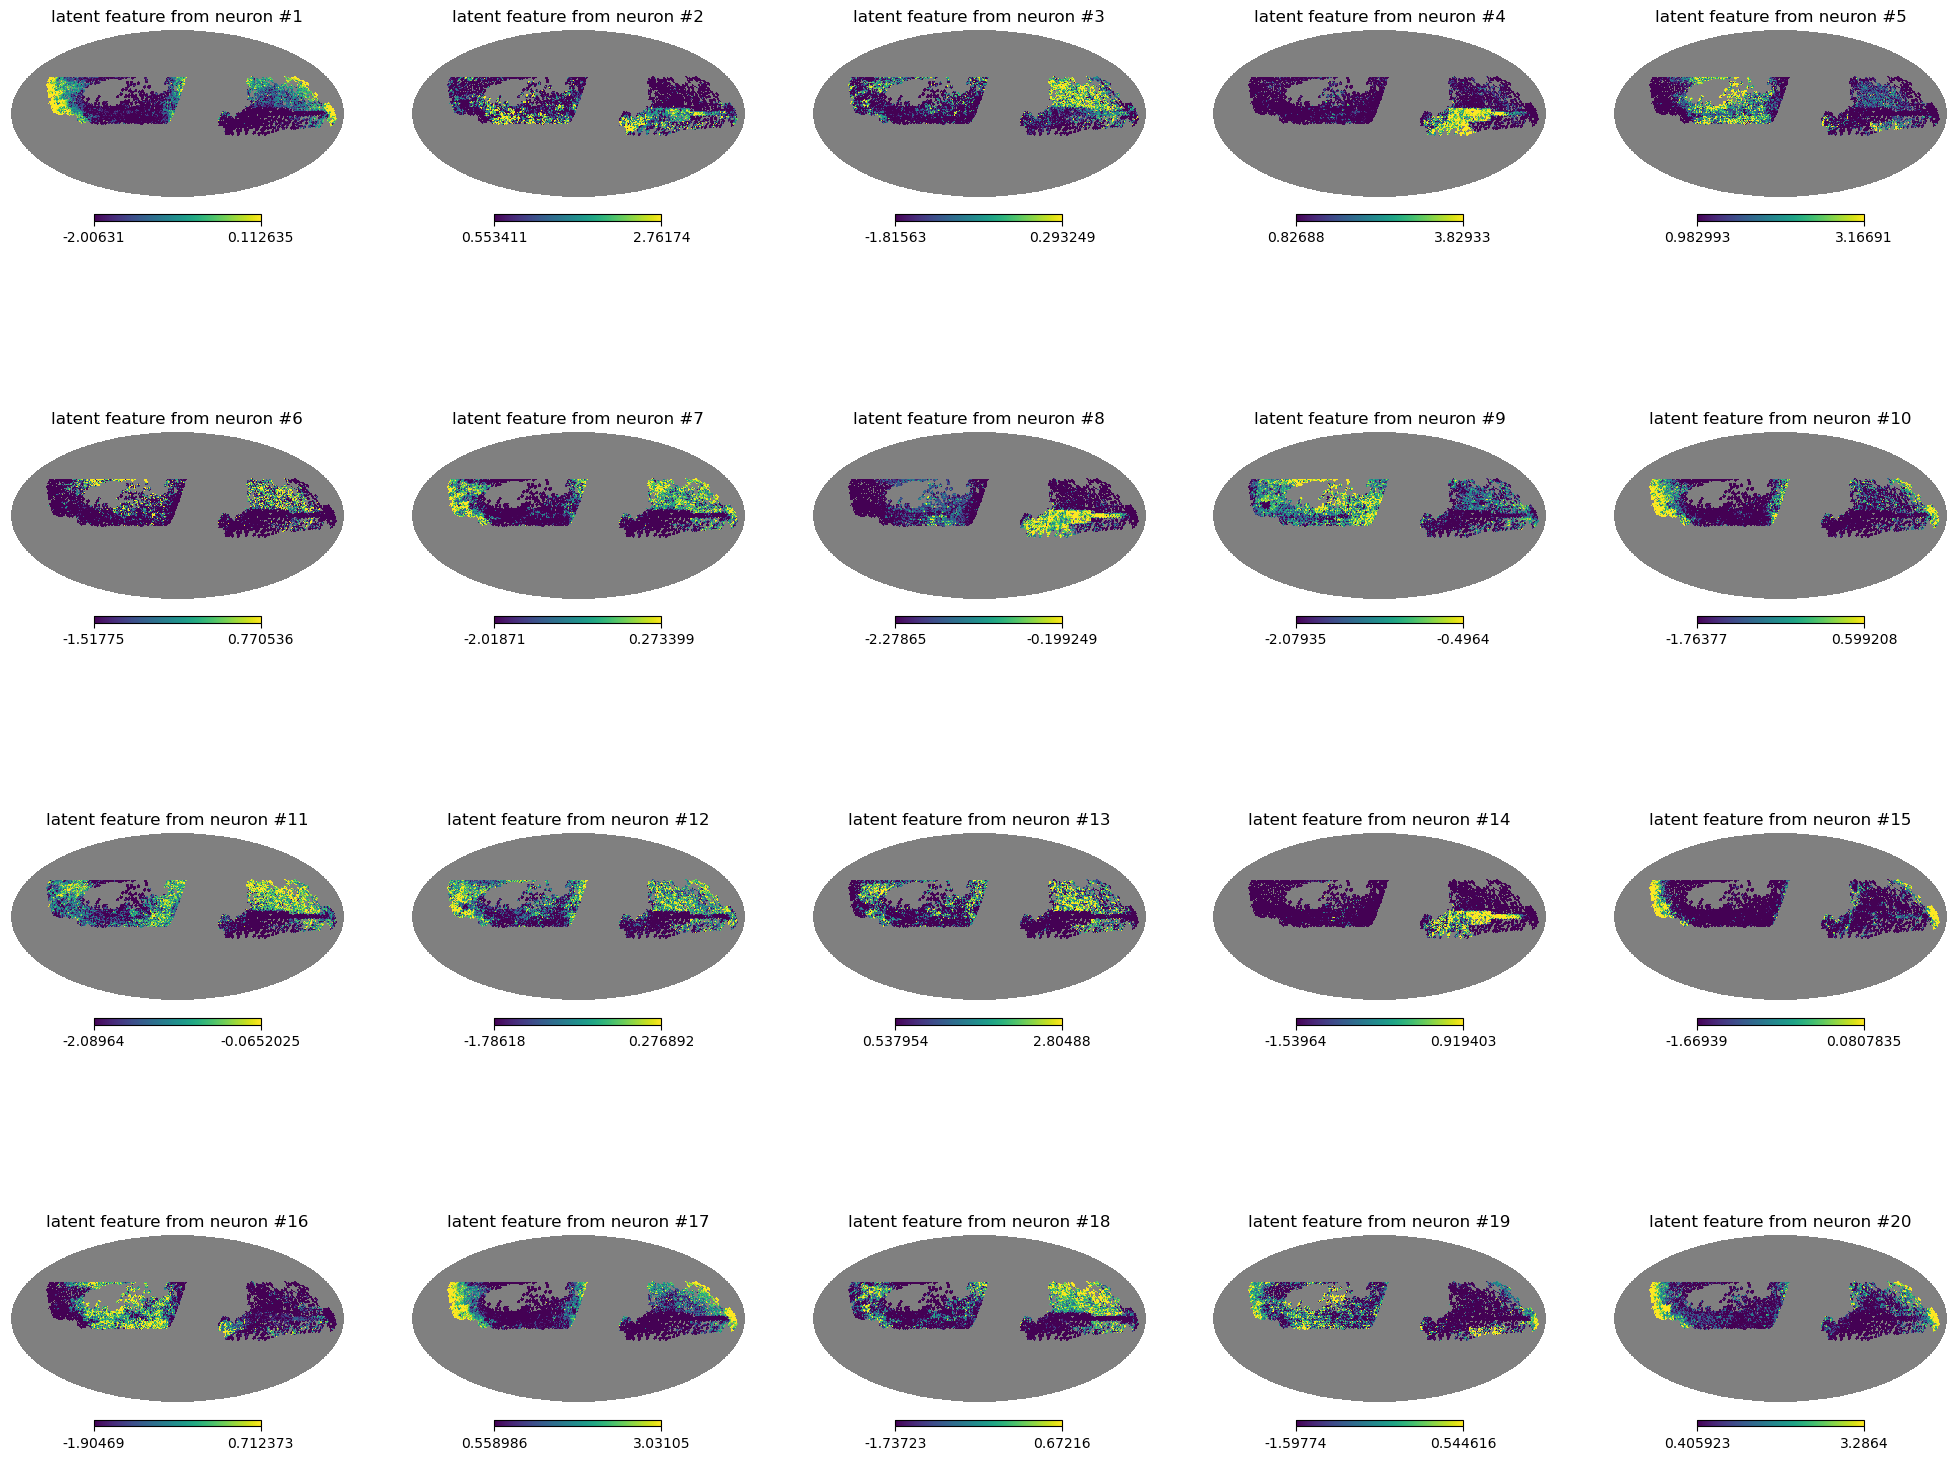

In [17]:
nplots = nn_struct[1]
ncols = math.ceil(math.sqrt(nplots))
nrows = math.ceil(nplots / ncols)
fig, ax = plt.subplots(nrows,ncols,figsize=(5*ncols, 5*nrows))
lax = ax.flatten()

# Region plots
for i in range(nplots):
    plot_hpmap(nside, hpix, latent[:,i], title=f'latent feature from neuron #{i+1}',ax=lax[i])
plt.subplots_adjust(hspace=0.0, wspace=0.0)
fig.savefig(plot_dir + f'/latent_space_features_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [18]:
# Now for NORTH
region = 'N'
sample = f'ELG_LOPnotqso1.1_1.6_{region}'
input_filename = sysnet_dir+f"prep_{sample}.fits"
input_ = ft.read(input_filename)  # read tab. data
num_features = (input_['features'].shape[1])
print(f'columns in `input`: {input_.dtype}')
print(f'number of features used in the regression {num_features}')

name_model = 'dnnp'
path_model = sysnet_dir+f'/{sample}/model_0_2664486226/best.pth.tar'
nn_struct = nn_struct_dict[region]
kw_model = dict(nnstruct=nn_struct, num_features=num_features)

tm = TrainedModel(name_model, path_model, **kw_model)
axes = [i for i in range(num_features)]  # all 18 imaging features used for training
hpix, npred, latent = tm.forward(input_filename, axes=axes, return_latent=True) 

columns in `input`: [('features', '>f8', (10,)), ('label', '>f8'), ('fracgood', '>f8'), ('hpix', '>i8')]
number of features used in the regression 10


0.0 42.46587882467083


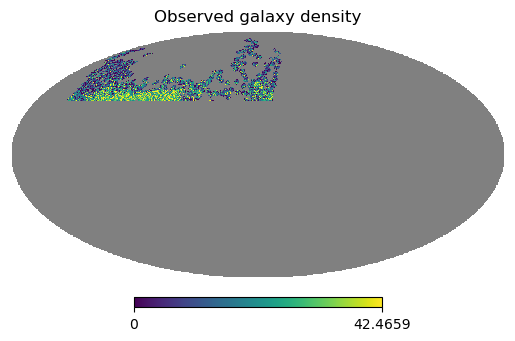

25.912696838378906 37.81122970581055


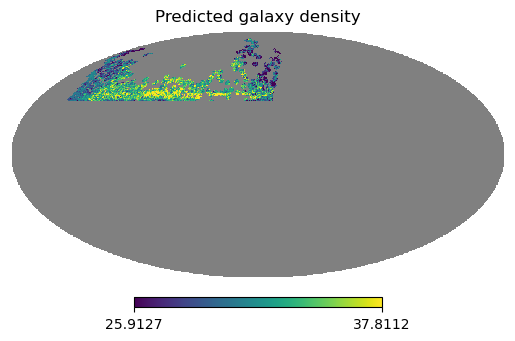

In [19]:
vlims=None
plot_hpmap(nside, input_['hpix'], input_['label'], vlims=vlims, title='Observed galaxy density')
plt.savefig(plot_dir + f'/dens_observed_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

plot_hpmap(nside, hpix, npred, vlims=vlims, title='Predicted galaxy density')
plt.savefig(plot_dir + f'/dens_predicted_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

-2.972264289855957 -0.7559406608343124
0.5728857517242432 3.3286452889442444
-1.762315034866333 -0.4725789725780487
-2.282055377960205 -0.9446082711219788
1.1920446157455444 3.1142603158950806
-2.2483012676239014 -0.03824523836374283
1.0265432596206665 3.285917341709137
-2.4010210037231445 -0.363985039293766
-1.8462705612182617 0.38167916238307953
-2.2639267444610596 -0.701370358467102


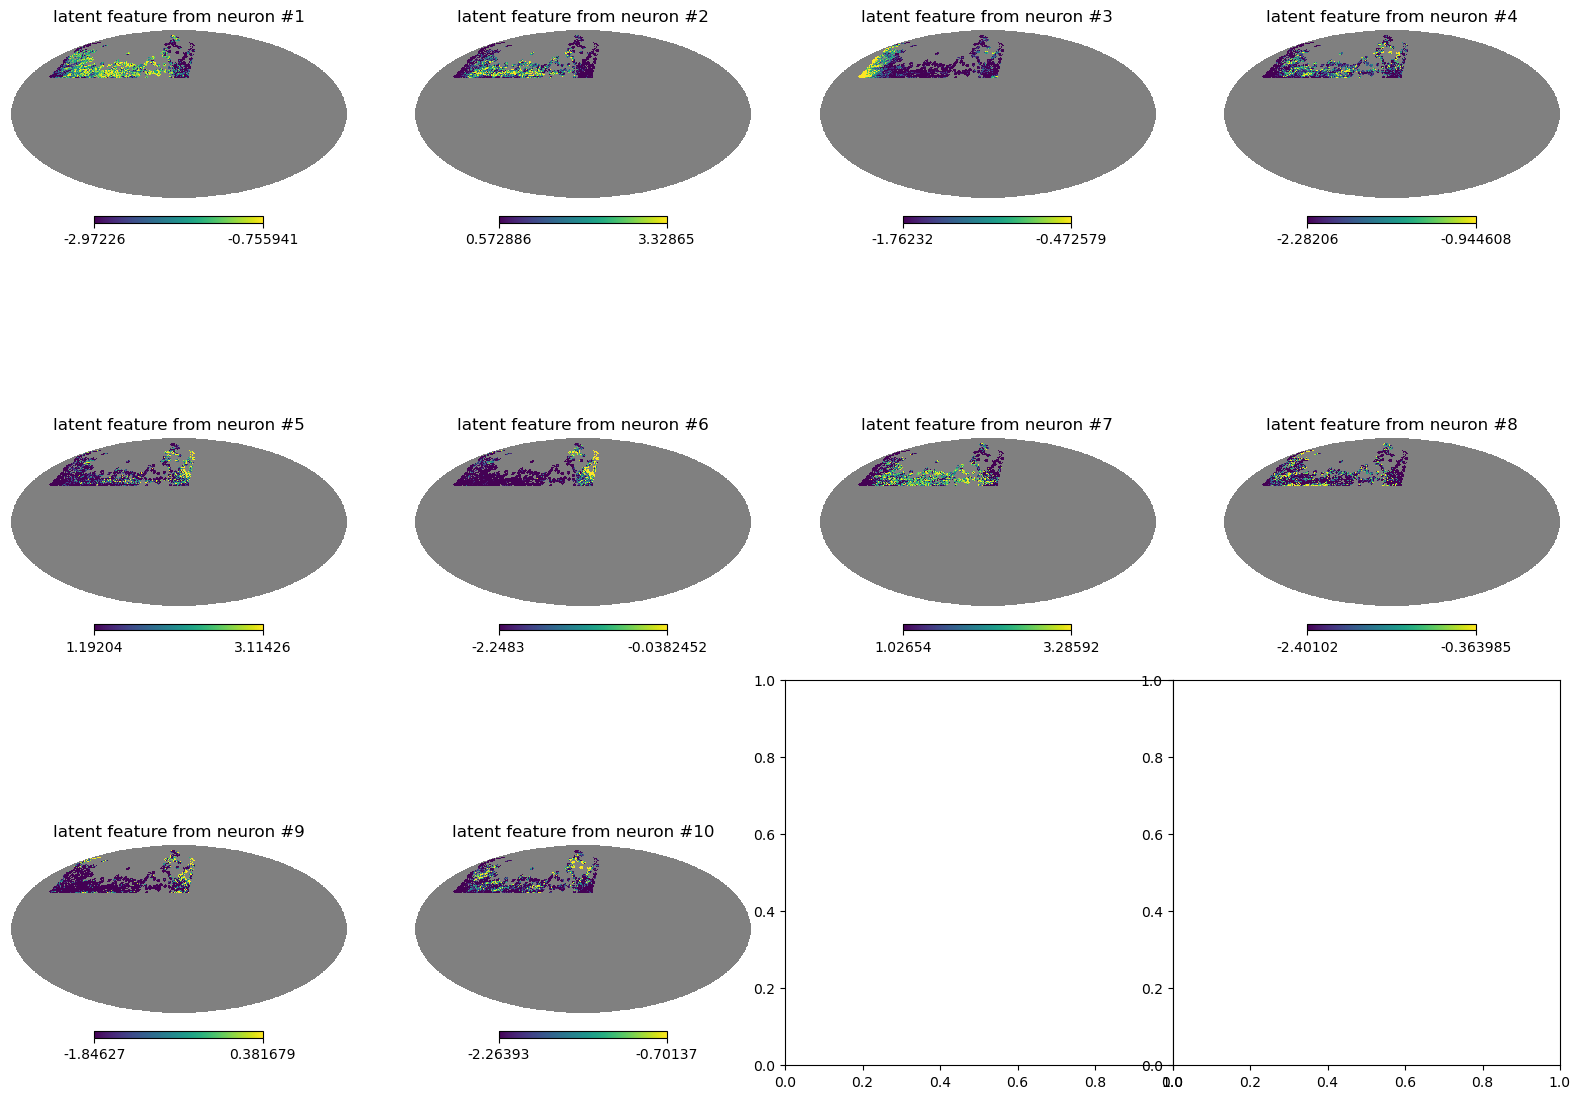

In [20]:
nplots = nn_struct[1]
ncols = math.ceil(math.sqrt(nplots))
nrows = math.ceil(nplots / ncols)
fig, ax = plt.subplots(nrows,ncols,figsize=(5*ncols, 5*nrows))
lax = ax.flatten()

# Region plots
for i in range(nplots):
    plot_hpmap(nside, hpix, latent[:,i], title=f'latent feature from neuron #{i+1}',ax=lax[i])
plt.subplots_adjust(hspace=0.0, wspace=0.0)
fig.savefig(plot_dir + f'/latent_space_features_dr1{region}.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [9]:
!ls /global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet/ELG_LOPnotqso1.1_1.6_S/model_0_2664486226/best.pth.tar

/global/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet/ELG_LOPnotqso1.1_1.6_S/model_0_2664486226/best.pth.tar


# Look at latent features from other chains

In [10]:
# Now with DESI DR1

nn_struct_dict = {'N': (3,10), 'S': (4,20)}
sysnet_dir = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet/'

region = 'S'
sample = f'ELG_LOPnotqso1.1_1.6_{region}'
input_filename = sysnet_dir+f"prep_{sample}.fits"
input_ = ft.read(input_filename)  # read tab. data
num_features = (input_['features'].shape[1])
axes = [i for i in range(num_features)]  # al imaging features used for training
nchains = 5

print(f'columns in `input`: {input_.dtype}')
print(f'number of features used in the regression {num_features}')

name_model = 'dnnp'
nn_struct = nn_struct_dict[region]
kw_model = dict(nnstruct=nn_struct, num_features=num_features)

partition = 0
__global_seed__ = 85
__seed_max__ = 4294967295 
np.random.seed(__global_seed__)
seeds = np.random.randint(0, __seed_max__, size=nchains)
latent_dict = {}
for chain_id in range(nchains):
    seed = seeds[chain_id] + 1000
    print(seed)
    path_model = sysnet_dir+f'/{sample}/model_{partition}_{seed}/best.pth.tar'
    
    tm = TrainedModel(name_model, path_model, **kw_model)
    
    hpix, npred, latent = tm.forward(input_filename, axes=axes, return_latent=True) 
    latent_dict[f'{chain_id}'] = (hpix,latent)
    # vlims=None
    # plot_hpmap(nside, hpix, npred, vlims=vlims, title='Predicted galaxy density')
    # plt.show()

columns in `input`: [('features', '>f8', (10,)), ('label', '>f8'), ('fracgood', '>f8'), ('hpix', '>i8')]
number of features used in the regression 10
2664486226
3865606280
2185937781
2285845164
1280952859


-2.006309986114502 0.11263457909225992
0.5534108877182007 2.761736512184142
-1.8156344890594482 0.2932494848966598
0.8268799185752869 3.829327178001403
0.982992947101593 3.1669068574905395
-1.5177464485168457 0.7705361247062672
-2.018714666366577 0.2733986854553186
-2.2786471843719482 -0.19924917370080988
-2.0793464183807373 -0.4963997721672059
-1.7637680768966675 0.5992080748081208
-2.089639902114868 -0.06520253345370383
-1.7861754894256592 0.2768916100263589
0.5379537343978882 2.804879856109619
-1.5396431684494019 0.9194029390811893
-1.6693923473358154 0.08078349232673505
-1.9046932458877563 0.7123733639717073
0.5589861273765564 3.0310487508773765
-1.737233281135559 0.6721596121788025
-1.5977448225021362 0.5446160614490465
0.40592339634895325 3.2863972187042236


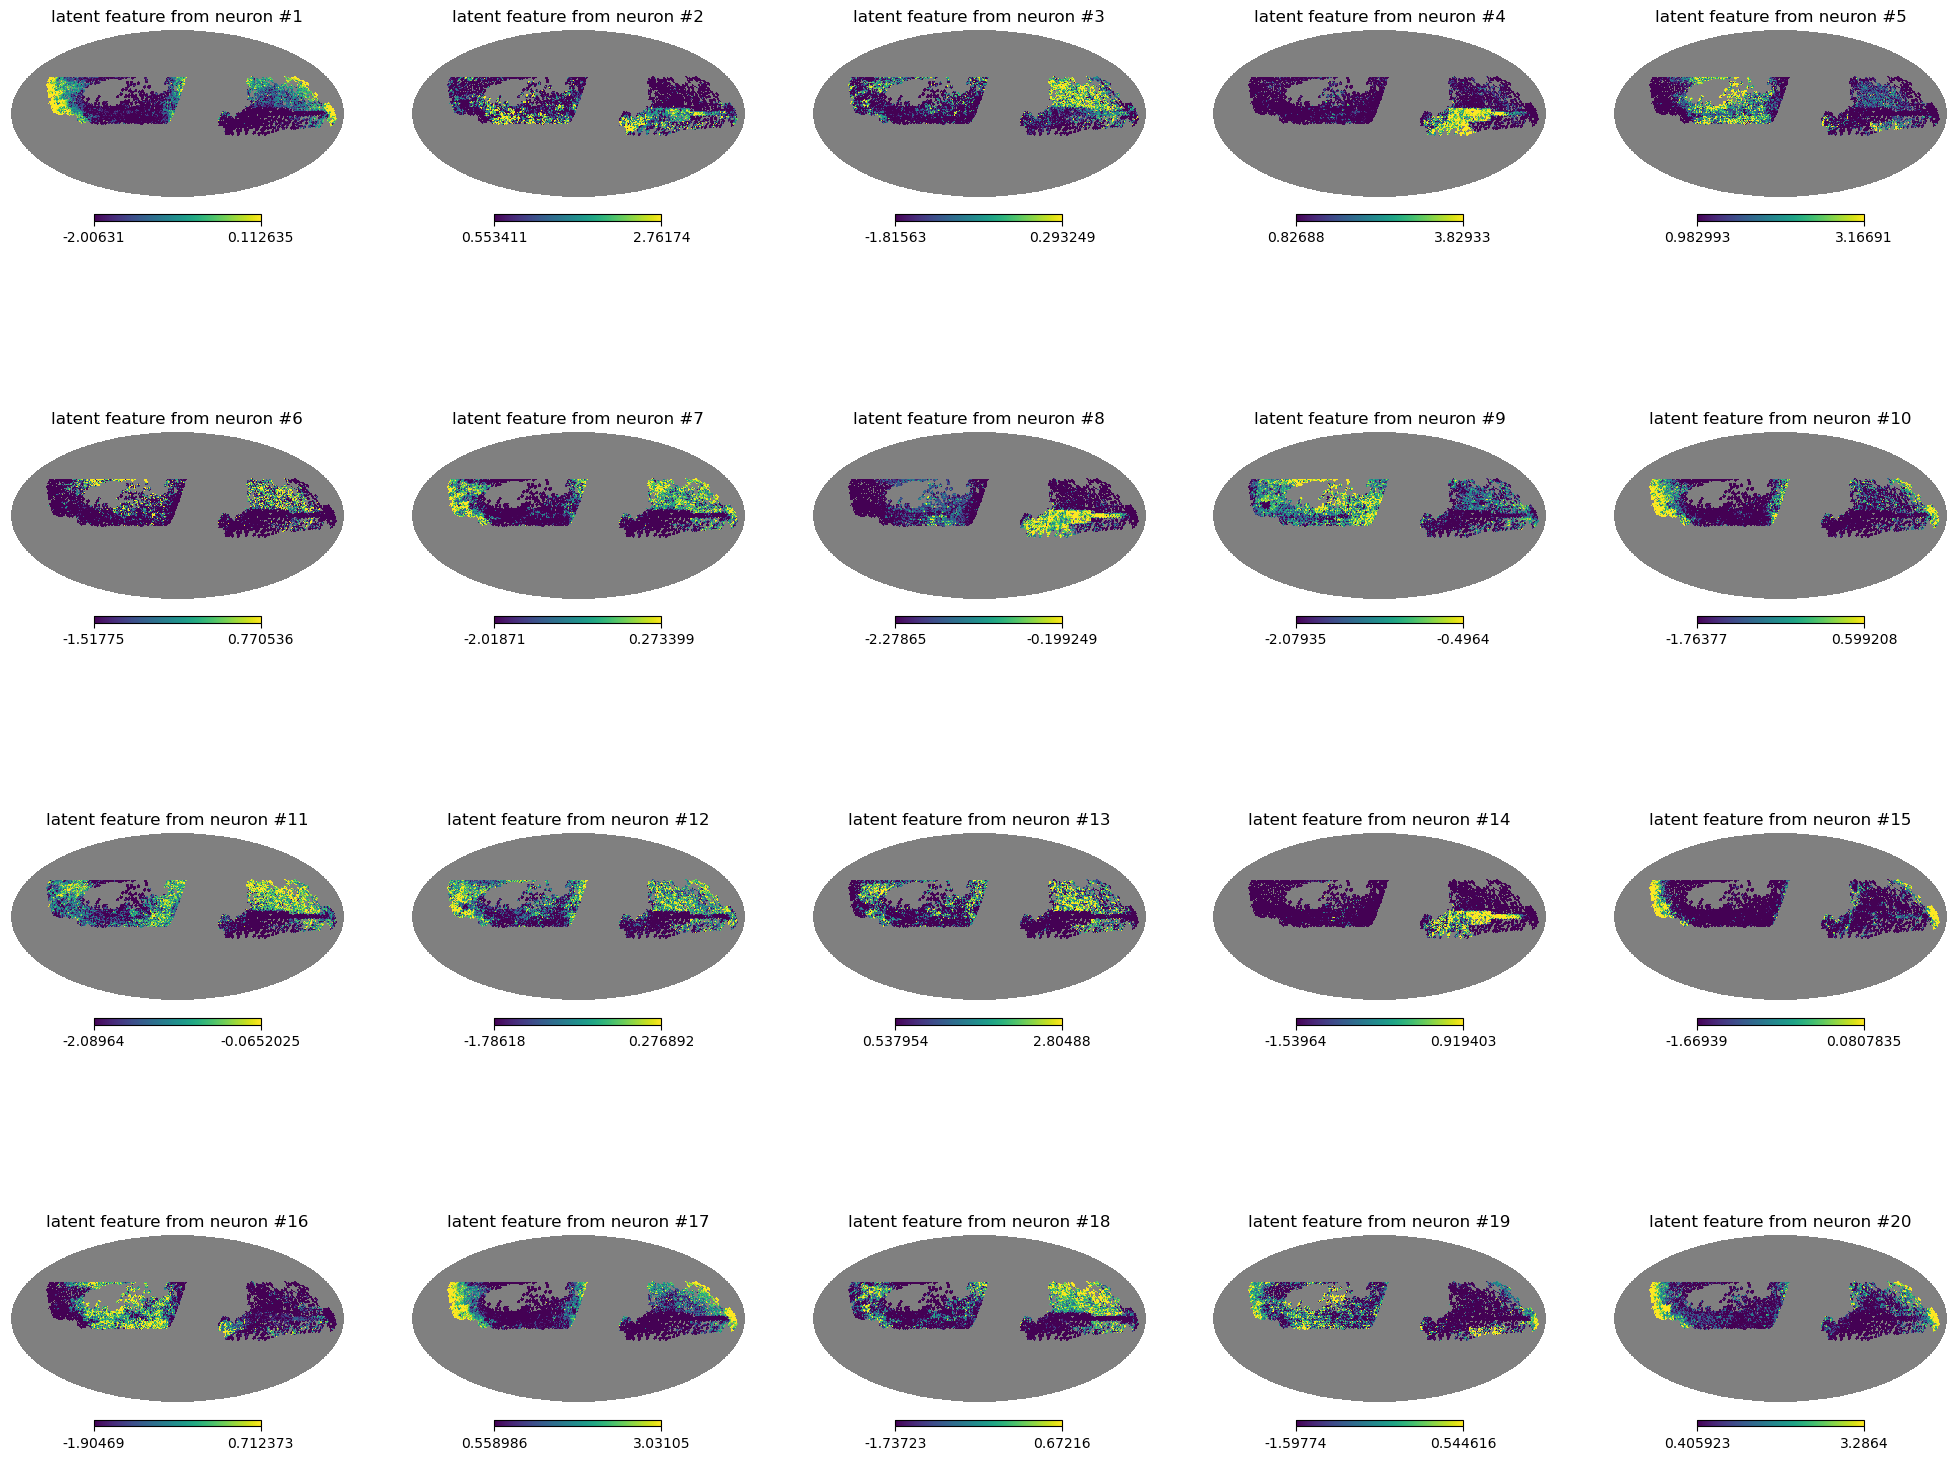

0.4319033622741699 2.8779760837554824
0.8288249373435974 3.161673736572265
-2.036813259124756 -0.1572927534580235
-1.8794368505477905 0.12310286015271907
0.5385002493858337 2.6913227796554566
-1.7424046993255615 0.9027867376804343
-1.4521560668945312 0.4458995521068535
-1.456427812576294 0.0894361987709936
0.7714821696281433 3.2101189613342243
0.6163507699966431 2.790069127082821
-1.641615629196167 0.8821155309677113
0.8033747673034668 3.1862404584884643
0.9910367131233215 3.178370594978332
0.7525036931037903 2.9949111223220823
-1.3387234210968018 0.3366641968488621
-1.820033311843872 1.0023160099983206
1.2420958280563354 3.331635069847099
0.5494567155838013 2.9837507486343378
-1.425258994102478 0.3175739318132358
0.7180603742599487 2.889383673667906


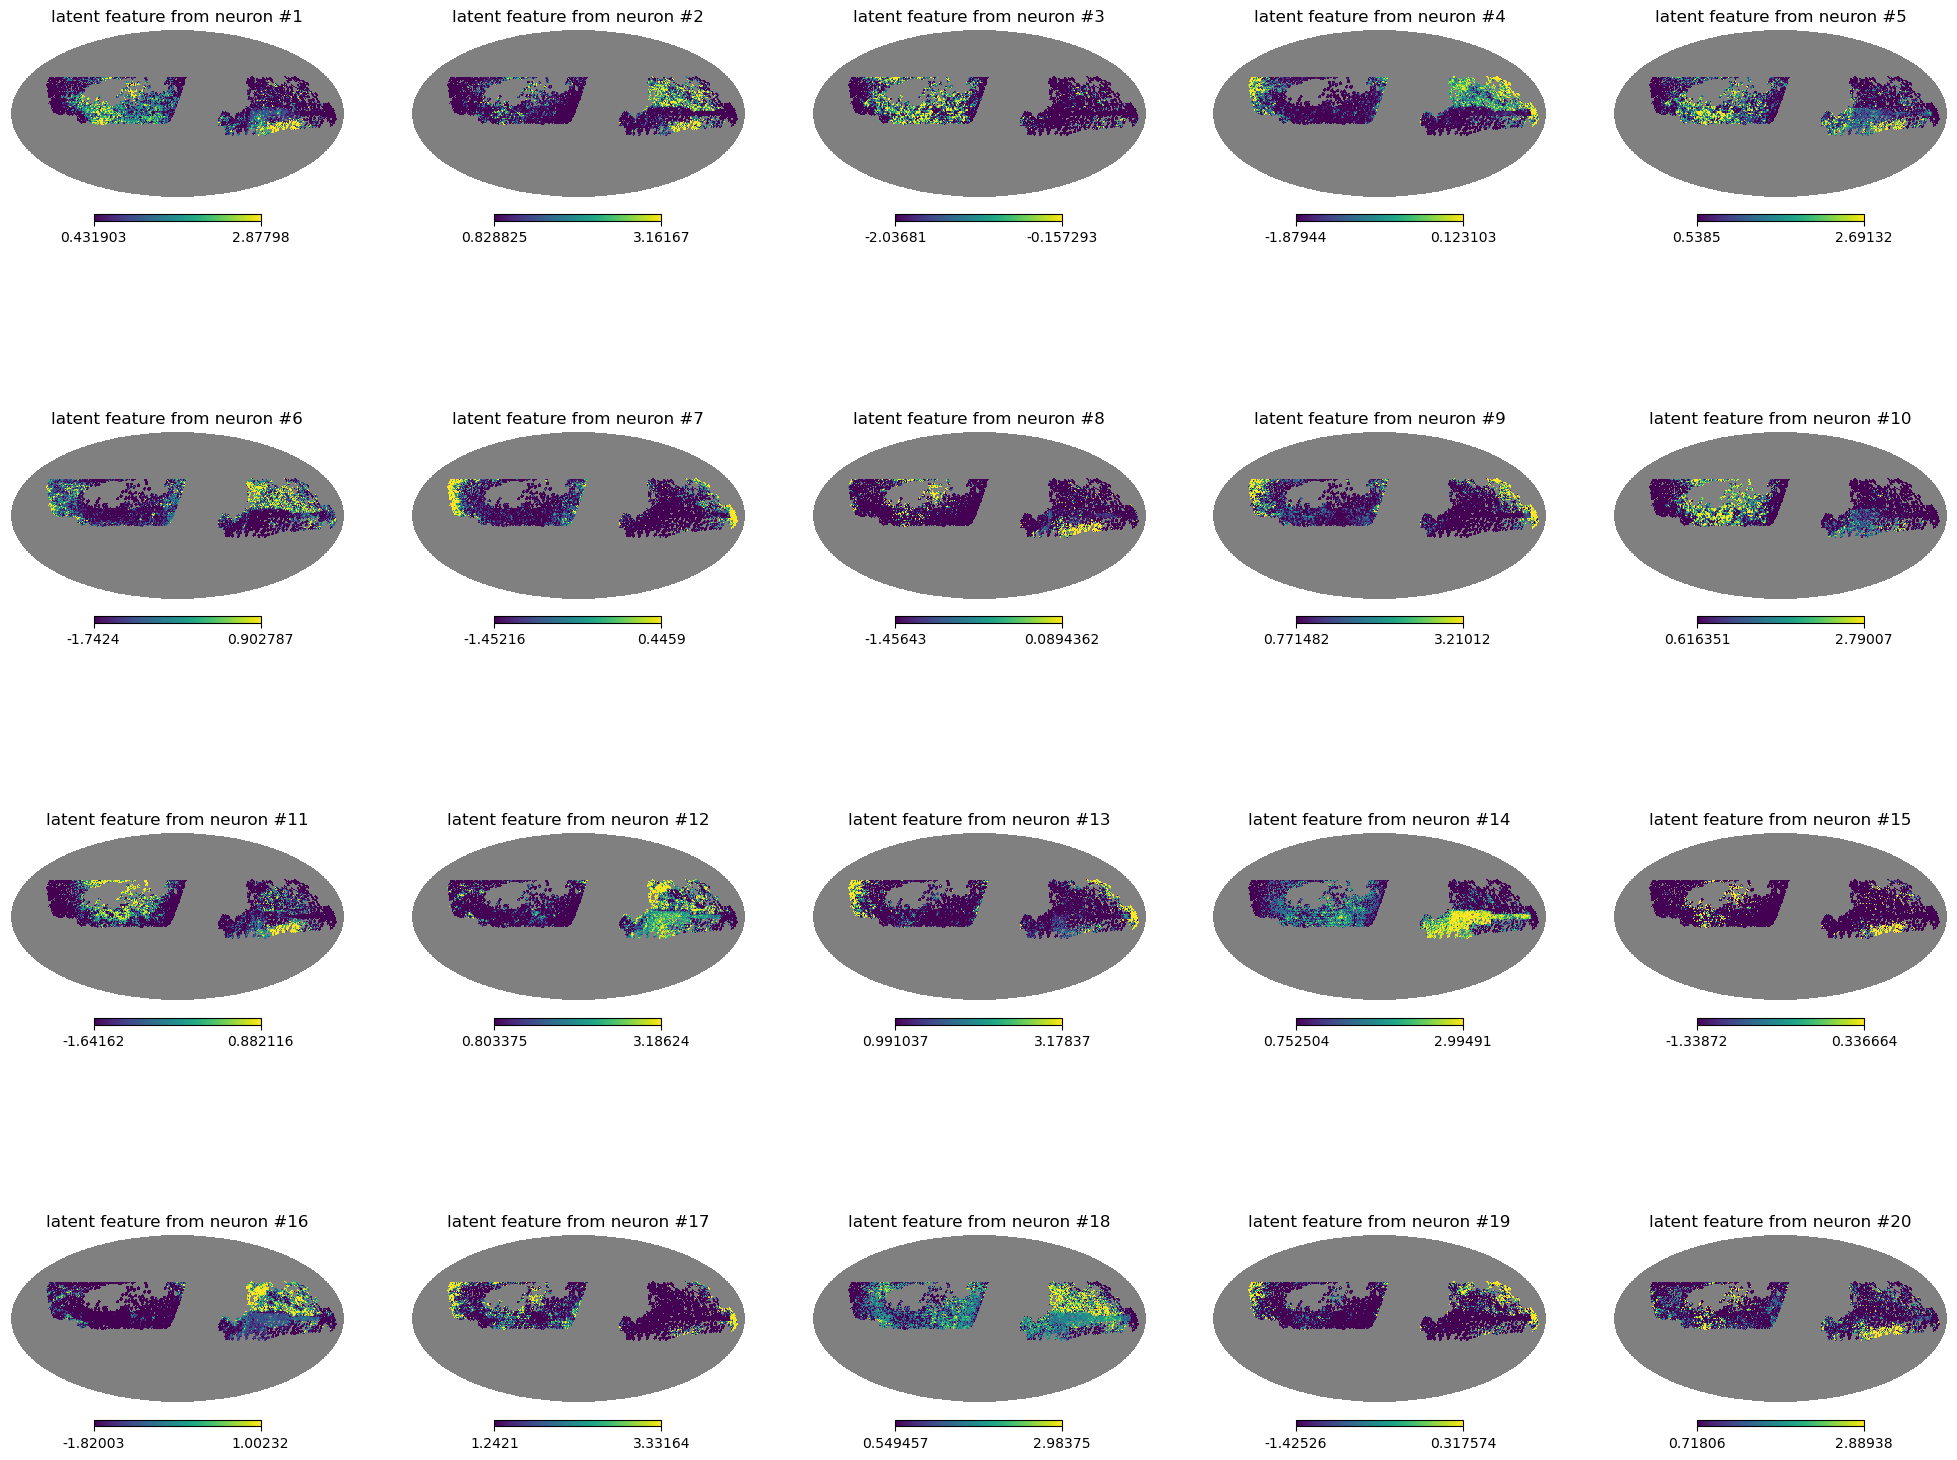

0.858323872089386 3.0816658973693833
0.7749749422073364 2.6924058914184568
0.855983316898346 3.4453787803649867
-1.4407798051834106 1.111680185794829
0.5640779137611389 2.513396024703979
0.8805578947067261 2.5422225236892655
-1.6948028802871704 1.020211100578307
-1.6041635274887085 1.0799342155456486
0.9564708471298218 3.0668914079666134
0.8110358119010925 3.3877416133880542
-1.8875558376312256 0.7258386790752399
0.6799131035804749 2.938095450401305
0.5956259965896606 2.7534029483795153
0.14072787761688232 2.86428415775299
0.9028634428977966 3.295984506607055
0.8777579069137573 2.647599911689758
0.7977944016456604 3.021790552139282
-1.780128836631775 0.8271159410476671
0.7557637095451355 2.781512761116025
0.23587994277477264 2.6992638349533076


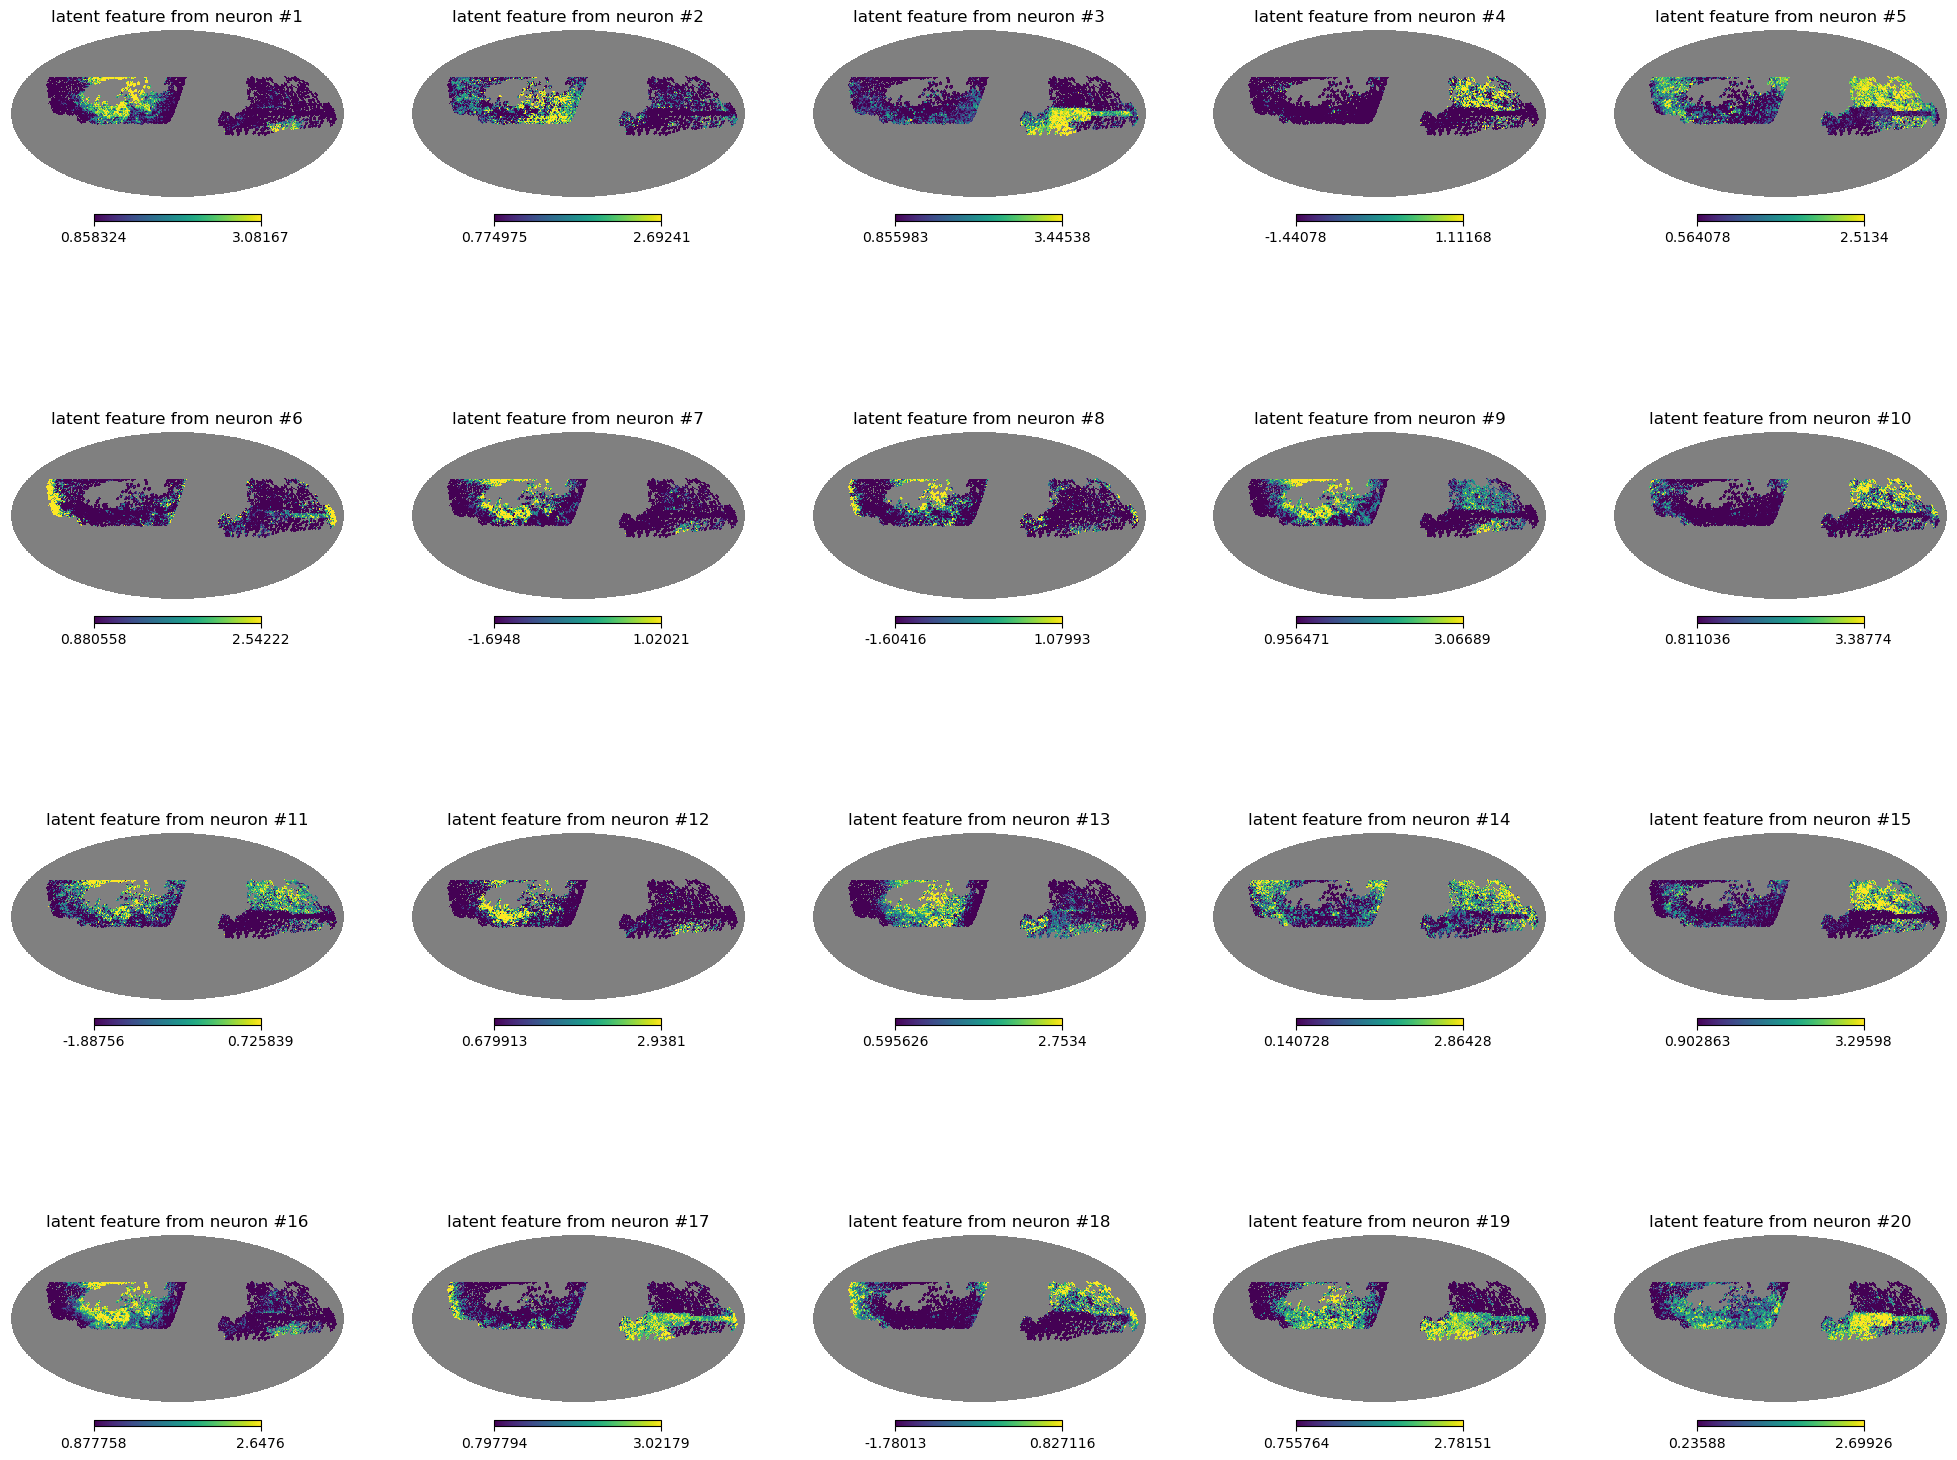

0.19528232514858246 2.738155889511104
-1.7863272428512573 0.6613642215728742
0.537566602230072 2.8081252813339224
-2.102388620376587 -0.39480612874031074
-1.7483258247375488 0.6996379971504212
-1.679663062095642 0.3156265020370419
0.7766910195350647 3.7705550432205173
-1.4561158418655396 0.48136960864066924
-1.8010191917419434 0.4185599923133843
-1.9289731979370117 0.30687359869480085
-1.6425591707229614 0.4665630519390084
0.991679310798645 2.9218247175216665
0.8946762681007385 3.655103564262387
1.2205286026000977 3.0287665367126433
0.8504794836044312 2.7824115753173815
-1.6000995635986328 0.5910657703876433
-1.8403184413909912 0.12043676301836667
0.6443887948989868 3.0236224651336663
0.7127565145492554 2.9838200330734255
-1.7851563692092896 0.6970473051071128


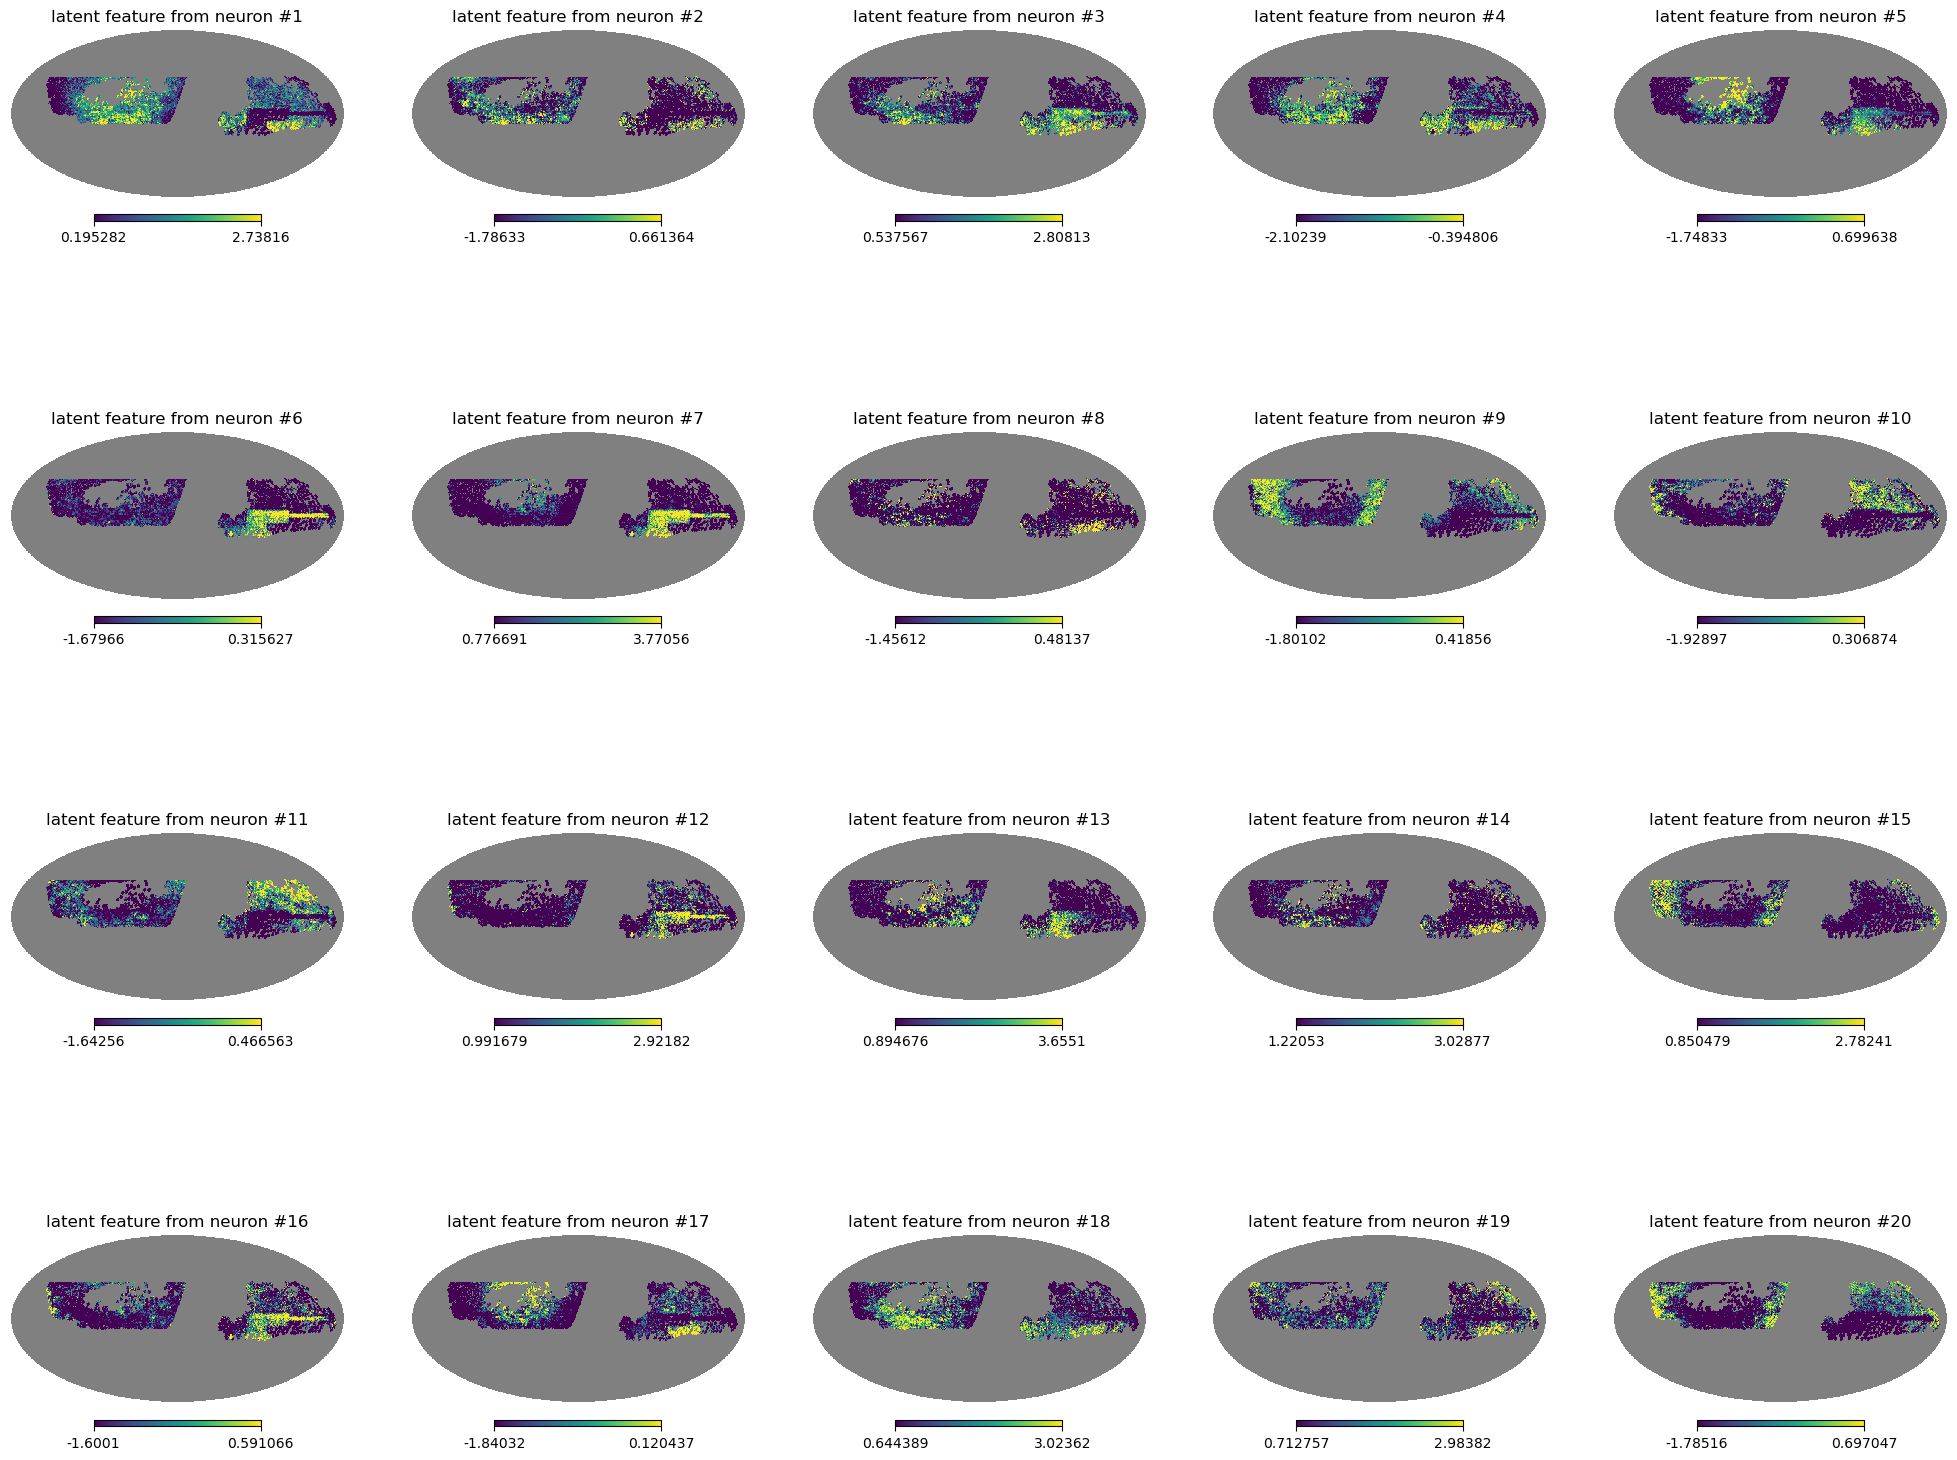

0.6598342657089233 2.5337320804595937
0.9806789755821228 2.5534440994262693
0.7790651917457581 3.6449954509735103
-1.6003055572509766 0.8086437582969649
-2.145576238632202 0.16458383202552765
0.9374457001686096 3.415035009384155
-1.8911590576171875 0.12452813014387559
-1.5639406442642212 0.8768099248409245
0.5276552438735962 2.776937770843505
1.08419930934906 3.752595973014826
-1.8637524843215942 0.8237655699253058
0.6211612820625305 3.1090217113494867
-2.1397173404693604 0.010136190522461928
0.6263818144798279 2.895194435119629
0.6358620524406433 3.1534538030624386
0.39720577001571655 2.737673473358152
-1.5417883396148682 0.8112495064735401
0.7571724653244019 2.957934021949764
-1.964128017425537 1.0524585843086234
-1.54789137840271 1.0219251275062557


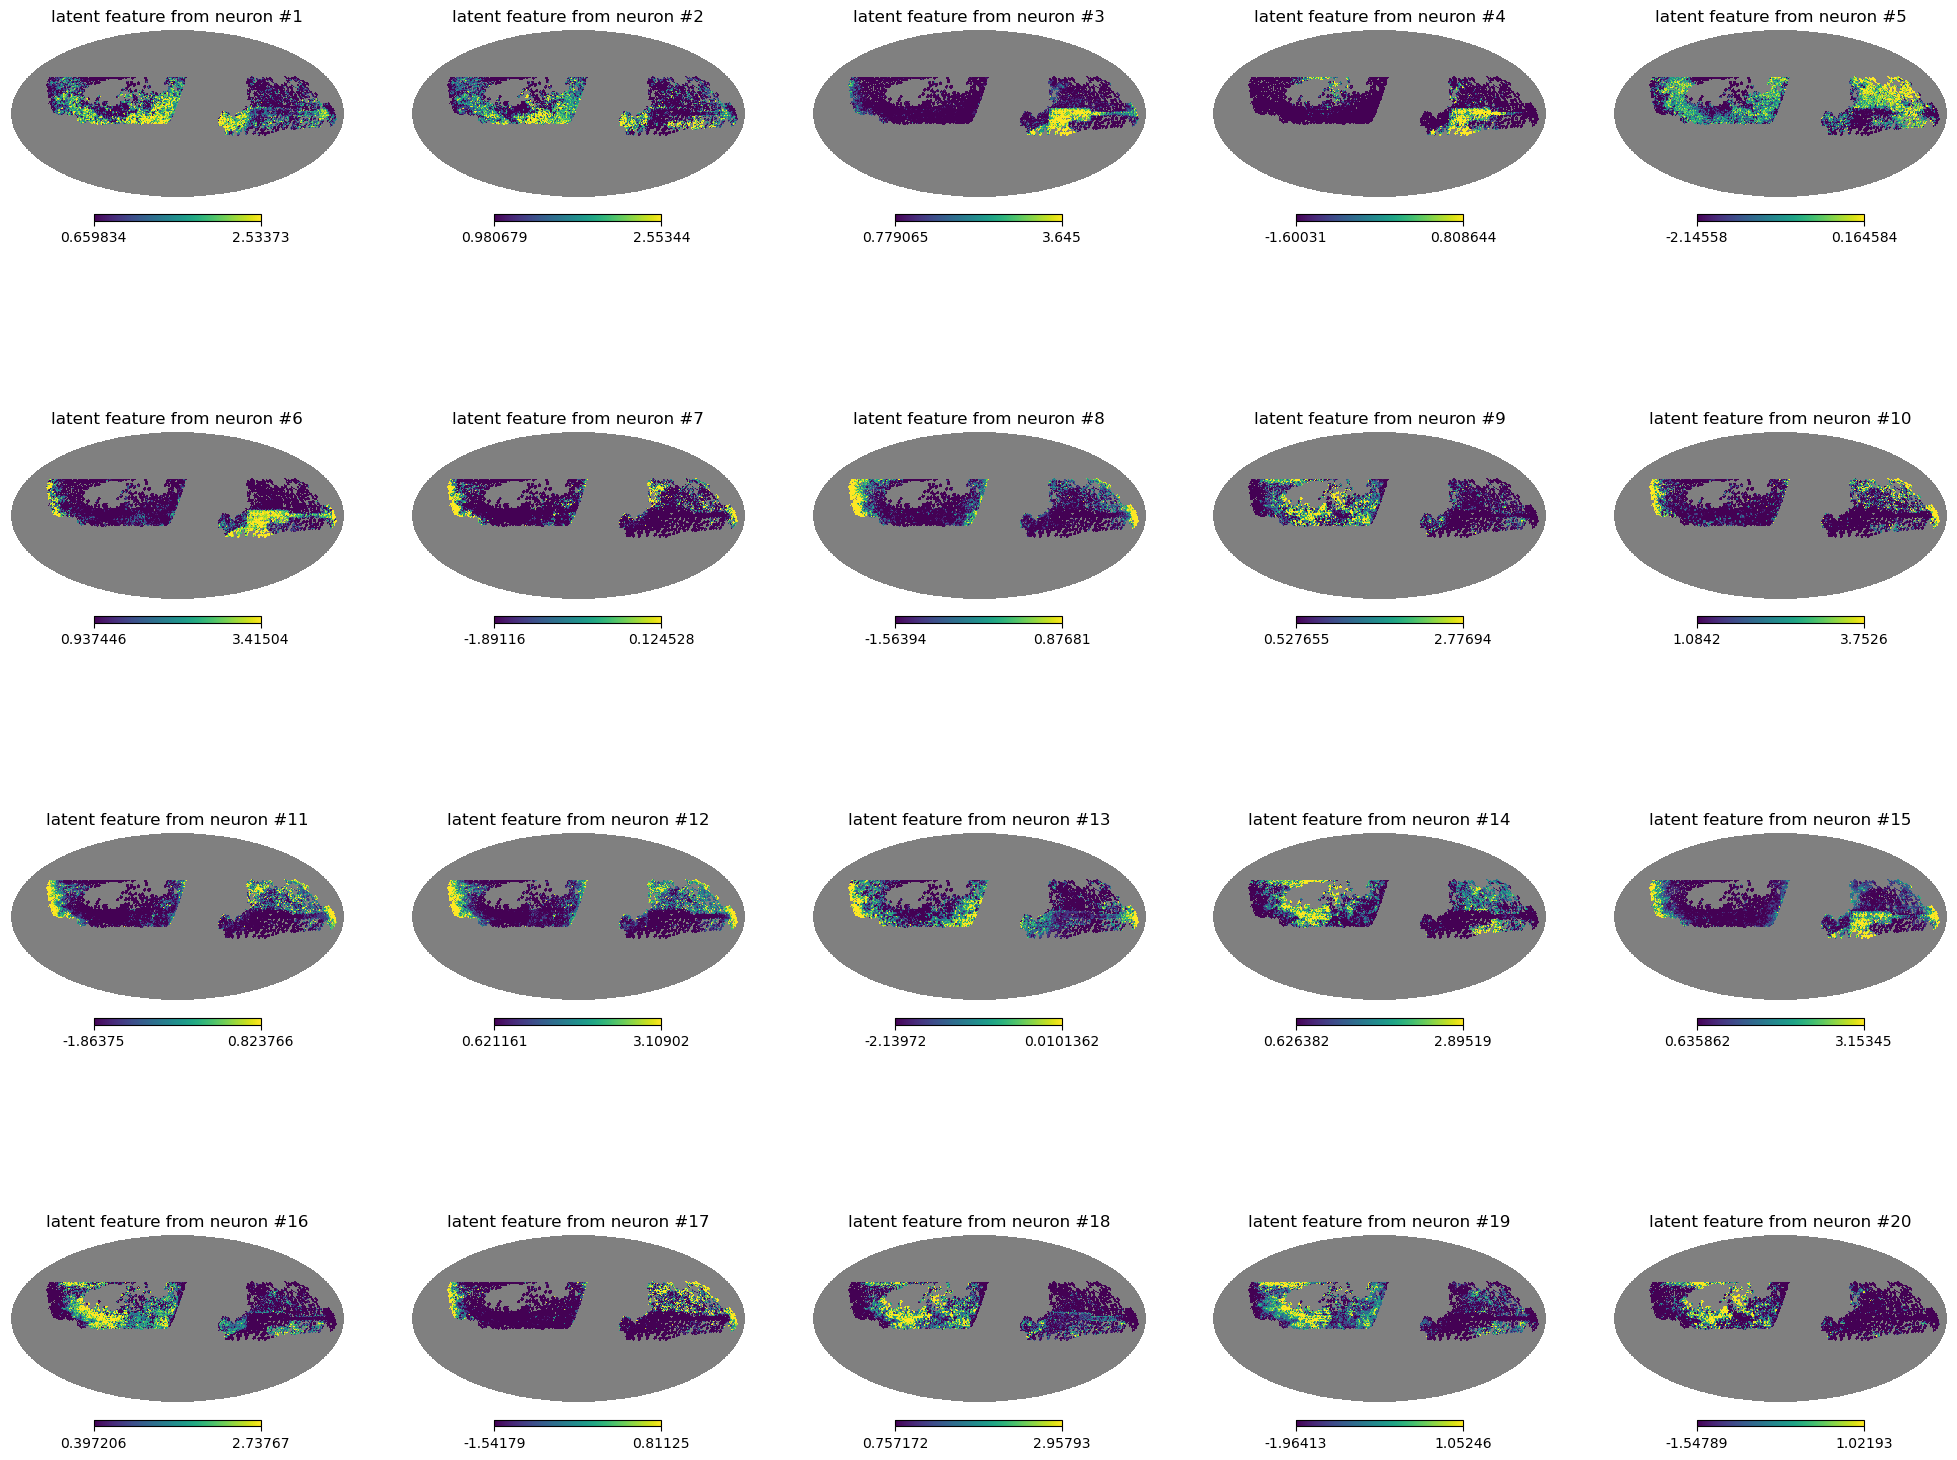

In [35]:
for chain_id in range(nchains):
    hpix, latent = latent_dict[f'{chain_id}']
    
    nplots = nn_struct[1]
    ncols = math.ceil(math.sqrt(nplots))
    nrows = math.ceil(nplots / ncols)
    fig, ax = plt.subplots(nrows,ncols,figsize=(5*ncols, 5*nrows))
    lax = ax.flatten()
    
    # Region plots
    for i in range(nplots):
        plot_hpmap(nside, hpix, latent[:,i], title=f'latent feature from neuron #{i+1}',ax=lax[i])
    plt.subplots_adjust(hspace=0.0, wspace=0.0)
    plt.show()

# Trying to combine pre-trained models and extract an ensemble of latent features

In [6]:
# Now with DESI DR1

nn_struct_dict = {'N': (3,10), 'S': (4,20)}
sysnet_dir = '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet/'

region = 'S'
sample = f'ELG_LOPnotqso1.1_1.6_{region}'
input_filename = sysnet_dir+f"prep_{sample}.fits"
input_ = ft.read(input_filename)  # read tab. data
num_features = (input_['features'].shape[1])
axes = [i for i in range(num_features)]  # al imaging features used for training
nchains = 5

print(f'columns in `input`: {input_.dtype}')
print(f'number of features used in the regression {num_features}')

name_model = 'dnnp'
nn_struct = nn_struct_dict[region]
kw_model = dict(nnstruct=nn_struct, num_features=num_features)

partition = 0
__global_seed__ = 85
__seed_max__ = 4294967295 
np.random.seed(__global_seed__)
seeds = np.random.randint(0, __seed_max__, size=nchains)
models_paths = []
for chain_id in range(nchains):
    seed = seeds[chain_id] + 1000
    print(seed)
    models_paths.append(sysnet_dir+f'/{sample}/model_{partition}_{seed}/best.pth.tar')
    
    # tm = TrainedModel(name_model, path_model, **kw_model)
    
    # hpix, npred, latent = tm.forward(input_filename, axes=axes, return_latent=True) 
    # latent_dict[f'{chain_id}'] = (hpix,latent)

columns in `input`: [('features', '>f8', (10,)), ('label', '>f8'), ('fracgood', '>f8'), ('hpix', '>i8')]
number of features used in the regression 10
2664486226
3865606280
2185937781
2285845164
1280952859


In [7]:
ensemble = LatentEnsemble(models_paths,nnstruct=nn_struct,num_features=num_features)

['/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet//ELG_LOPnotqso1.1_1.6_S/model_0_2664486226/best.pth.tar',
 '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet//ELG_LOPnotqso1.1_1.6_S/model_0_3865606280/best.pth.tar',
 '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet//ELG_LOPnotqso1.1_1.6_S/model_0_2185937781/best.pth.tar',
 '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet//ELG_LOPnotqso1.1_1.6_S/model_0_2285845164/best.pth.tar',
 '/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y1/LSS/iron/LSScats/v1.5/sysnet//ELG_LOPnotqso1.1_1.6_S/model_0_1280952859/best.pth.tar']

In [3]:
load_checkpoint(

<function sysnet.sources.io.load_checkpoint(checkpoint, model, optimizer=None, scheduler=None)>